In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
train_df=pd.read_csv("sign_mnist_train.csv")
test_df=pd.read_csv("sign_mnist_test.csv")

In [ ]:
X_train = train_df.drop("label", axis=1).values/255.0
y_train = train_df["label"].values
X_test = test_df.drop("label", axis=1).values/255.0
y_test = test_df["label"].values

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
num_classes = np.max(y_train) + 1
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(int(num_classes), activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, y_train_cat, epochs=10, validation_data=(X_test, y_test_cat), batch_size=64)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.1511 - loss: nan - val_accuracy: 0.0462 - val_loss: nan
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.0410 - loss: nan - val_accuracy: 0.0462 - val_loss: nan
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.0410 - loss: nan - val_accuracy: 0.0462 - val_loss: nan
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.0410 - loss: nan - val_accuracy: 0.0462 - val_loss: nan
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.0410 - loss: nan - val_accuracy: 0.0462 - val_loss: nan
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.0410 - loss: nan - val_accuracy: 0.0462 - val_loss: nan
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.0410 - loss: nan - val_accuracy: 0.0462 - val_loss: nan
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.0410 - loss: nan - val_accuracy: 0.0462 - val_loss: nan
Epoch 9/10


In [ ]:
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {acc * 100:.2f}%")

Test Accuracy: 4.62%


In [ ]:
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test, y_pred_classes))

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
              precision    recall  f1-score   support

           0       0.05      1.00      0.09       331
           1       0.00      0.00      0.00       432
           2       0.00      0.00      0.00       310
           3       0.00      0.00      0.00       245
           4       0.00      0.00      0.00       498
           5       0.00      0.00      0.00       247
           6       0.00      0.00      0.00       348
           7       0.00      0.00      0.00       436
           8       0.00      0.00      0.00       288
          10       0.00      0.00      0.00       331
          11       0.00      0.00      0.00       209
          12       0.00      0.00      0.00       394
          13       0.00      0.00      0.00       291
          14       0.00      0.00      0.00       246
          15       0.00      0.00      0.00       347
          16       0.00      0.00      0.00       164
          17       0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


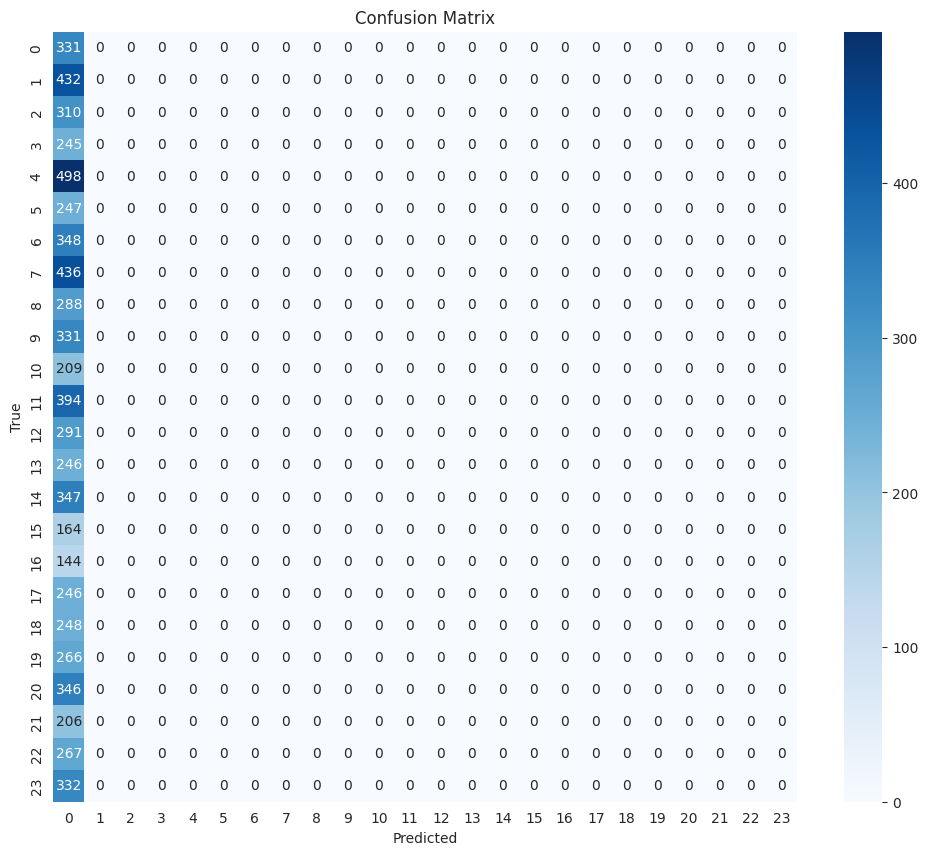

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()